## Analysis

This Jupyter Notebook presents the analysis of the serial job for Monte Carlo simulation and data.
The focus is on read throughput and file size.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import os
from matplotlib.ticker import AutoMinorLocator

In [2]:
#read the MC file size csv

file_size_MC=pd.read_csv("../file_size_MC.csv")
file_size_MC

,Algo,AOD_type,7000events_level1,7000events_level5,7000events_level9,28000events_level1,28000events_level5,28000events_level9,56000events_level1,56000events_level5,56000events_level9,112000events_level1,112000events_level5,112000events_level9
0,LZMA,TTree,2.774337,NaN,NaN,10.987967,NaN,NaN,22.092319,NaN,NaN,44.255563,NaN,NaN
1,LZMA,Rntuple,2.437226,2.354952,2.347708,9.647785,9.315798,9.286690,19.408100,18.735929,18.682283,38.872853,37.541994,37.449057
2,ZSTD,Rntuple,2.559670,2.475831,2.395001,10.137155,9.796508,9.475843,20.386879,19.702836,19.052694,40.847885,39.475962,38.161572
3,LZ4,Rntuple,3.022727,2.718142,2.665734,11.969192,10.762128,10.552012,24.068130,21.643794,21.221410,48.194308,43.360520,42.529596
4,ZLib,Rntuple,2.597361,2.495657,2.465770,10.283489,9.876100,9.756110,20.683076,19.862994,19.626503,41.437953,39.785751,39.298940


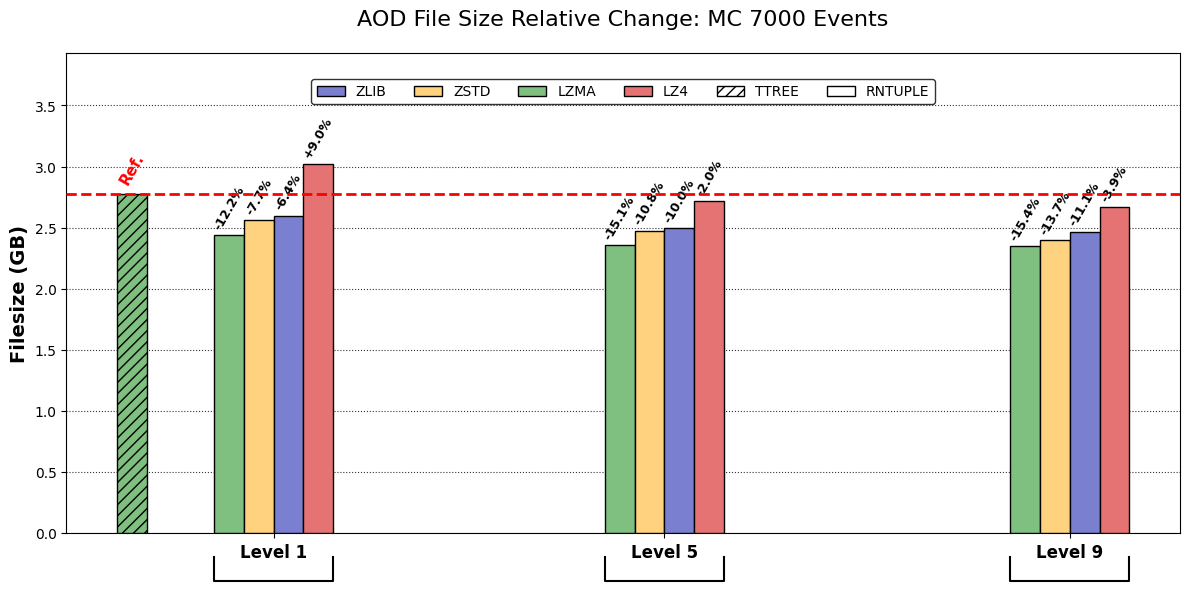

In [3]:
#Mc File size Plots

df = file_size_MC.copy()
df['Algo'] = df['Algo'].str.lower()
df['AOD_type'] = df['AOD_type'].str.lower()

algorithms = ["zlib", "zstd", "lzma", "lz4"]
levels = [1, 5, 9]
formats = ["ttree", "rntuple"]
event_counts = [7000]

colors = {"zlib": "#7b7fcf", "zstd": "#ffd27f", "lzma": "#7fbf7f", "lz4": "#e57373"}
hatches = {"ttree": "///", "rntuple": ""}

for num_events in event_counts:
    plot_data_per_level = {lvl: [] for lvl in levels}
    found_any_data = False
    ref_value = 0
    max_in_this_plot = 0  

    for lvl in levels:
        for algo in algorithms:
            for fmt in formats:
                col_name = f"{num_events}events_level{lvl}"
                try:
                    val = df.loc[(df['Algo'] == algo) & (df['AOD_type'] == fmt), col_name]
                    if not val.empty and not pd.isna(val.values[0]):
                        size_gb = float(val.values[0])
                        if size_gb > 0:
                            plot_data_per_level[lvl].append({'val': size_gb, 'algo': algo, 'fmt': fmt, 'lvl': lvl})
                            found_any_data = True
                            if size_gb > max_in_this_plot:
                                max_in_this_plot = size_gb
                            if algo == "lzma" and fmt == "ttree" and lvl == 1:
                                ref_value = size_gb
                except KeyError:
                    continue

    if not found_any_data or ref_value == 0:
        continue

    fig, ax = plt.subplots(figsize=(12, 6))
    
    bar_width = 0.22           
    group_spacing = 3.0    
    x_centers = np.arange(len(levels)) * group_spacing
    gap_width = 0.5
    
    bracket_centers = [] 

    for l_idx, lvl in enumerate(levels):
        valid_bars = plot_data_per_level[lvl]
        valid_bars.sort(key=lambda x: (x['fmt'] != 'ttree', x['val']))
        
        num_bars = len(valid_bars)
        if num_bars == 0: continue
            
        start_offset = -((num_bars - 1) * bar_width) / 2
        
        # Track separate min/max for RNtuple bars to exclude TTree from the bracket
        rntuple_x_coords = []
        all_x_coords = []

        for b_idx, bar in enumerate(valid_bars):
            offset = start_offset + (b_idx * bar_width)
            extra_gap = gap_width if bar['fmt'] != 'ttree' else 0
            curr_x = x_centers[l_idx] + offset + extra_gap
            
            all_x_coords.append(curr_x)
            if bar['fmt'] == 'rntuple':
                rntuple_x_coords.append(curr_x)
            
            ax.bar(curr_x, bar['val'], bar_width, color=colors[bar['algo']],  
                   hatch=hatches[bar['fmt']], edgecolor="black", zorder=3)

            is_baseline = (bar['algo'] == "lzma" and bar['fmt'] == "ttree" and bar['lvl'] == 1)
            if not is_baseline:
                diff_pct = ((bar['val'] - ref_value) / ref_value) * 100
                ax.text(curr_x, bar['val'] + (max_in_this_plot * 0.01), f"{diff_pct:+.1f}%", 
                           ha="center", va="bottom", fontsize=9, fontweight='bold', rotation=60, zorder=4)
            else:
                ax.text(curr_x, bar['val'] + (max_in_this_plot * 0.02), "Ref.", color="red", 
                           ha="center", va="bottom", fontsize=11, fontweight="bold", rotation=60)
        
        # Calculate the bracket lines using ONLY the RNtuple bar coordinates
        bracket_pad = bar_width / 2
        min_rntuple_x = min(rntuple_x_coords) if rntuple_x_coords else x_centers[l_idx]
        max_rntuple_x = max(rntuple_x_coords) if rntuple_x_coords else x_centers[l_idx]
        
        ax.plot([min_rntuple_x - bracket_pad, min_rntuple_x - bracket_pad, max_rntuple_x + bracket_pad, max_rntuple_x + bracket_pad], 
                [-0.05, -0.1, -0.1, -0.05], color='black', transform=ax.get_xaxis_transform(), clip_on=False)
        
        # Center the X-axis label perfectly underneath the whole structural group
        bracket_centers.append((min_rntuple_x - bracket_pad + max_rntuple_x + bracket_pad) / 2)

    ax.axhline(ref_value, color="red", linestyle="--", linewidth=2, zorder=5)
    ax.yaxis.grid(True, linestyle=":", color="black", alpha=0.8, zorder=0)

    ax.set_xticks(bracket_centers)
    ax.set_xticklabels([f"Level {l}" for l in levels], fontsize=12, fontweight="bold")
    
    ax.set_ylabel("Filesize (GB)", fontsize=14, fontweight="bold")
    ax.set_title(f"AOD File Size Relative Change: MC {num_events} Events", fontsize=16, pad=20)
    
    ax.set_ylim(0, max_in_this_plot * 1.3)

    algo_patches = [Patch(facecolor=colors[a], label=a.upper(), edgecolor="black") for a in algorithms]
    format_patches = [Patch(facecolor="white", edgecolor="black", hatch=hatches[f], label=f.upper()) for f in formats]
    
    ax.legend(handles=algo_patches + format_patches, loc='upper center', 
                ncol=6, frameon=True, edgecolor="black", bbox_to_anchor=(0.5, 0.96))

    plt.tight_layout()
    plt.show()

In [4]:
#read the data file size csv

file_size_data=pd.read_csv("../file_size_data.csv")
file_size_data

,Algo,AOD_type,7000events_level1,7000events_level5,7000events_level9
0,LZMA,TTree,2.682739,NaN,NaN
1,LZMA,Rntuple,2.289019,2.218654,2.213180
2,ZSTD,Rntuple,2.393877,2.318924,2.256036
3,LZ4,Rntuple,2.775860,2.530587,2.489795
4,ZLib,Rntuple,2.421975,2.336335,2.307545


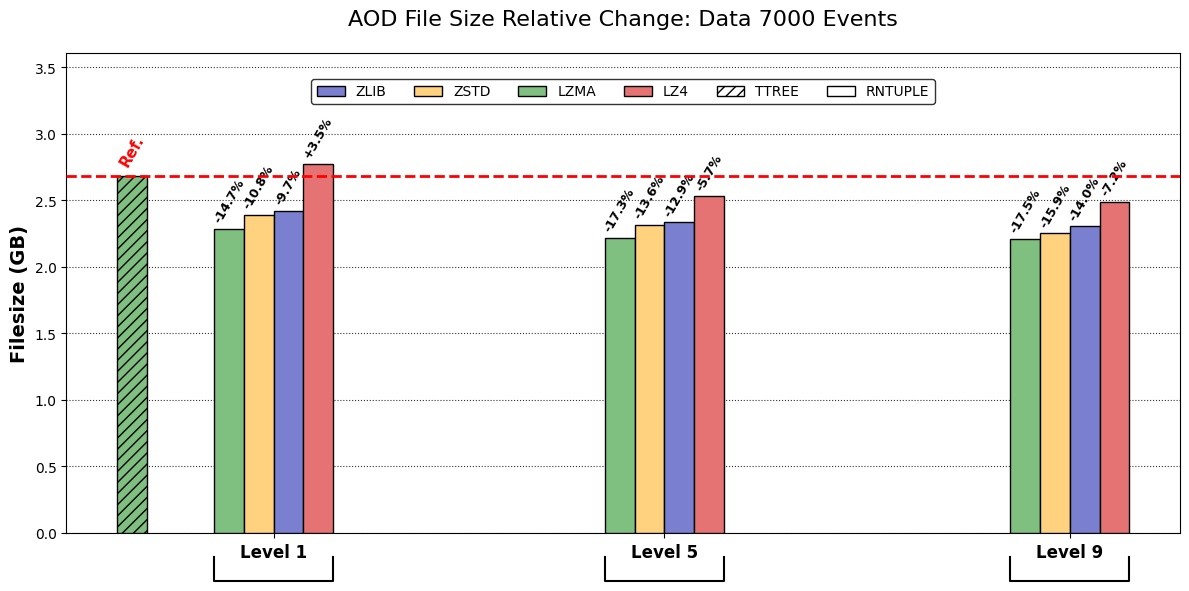

In [5]:
#Data File size Plots

df = pd.read_csv("../file_size_data.csv")
df['Algo'] = df['Algo'].str.lower()
df['AOD_type'] = df['AOD_type'].str.lower()


algorithms = ["zlib", "zstd", "lzma", "lz4"]
levels = [1, 5, 9]
formats = ["ttree", "rntuple"]
event_counts = [7000]

colors = {"zlib": "#7b7fcf", "zstd": "#ffd27f", "lzma": "#7fbf7f", "lz4": "#e57373"}
hatches = {"ttree": "///", "rntuple": ""}

for num_events in event_counts:
    plot_data_per_level = {lvl: [] for lvl in levels}
    found_any_data = False
    ref_value = 0
    max_in_this_plot = 0  

    for lvl in levels:
        for algo in algorithms:
            for fmt in formats:
                col_name = f"{num_events}events_level{lvl}"
                try:
                    val = df.loc[(df['Algo'] == algo) & (df['AOD_type'] == fmt), col_name]
                    if not val.empty and not pd.isna(val.values[0]):
                        size_gb = float(val.values[0])
                        if size_gb > 0:
                            plot_data_per_level[lvl].append({'val': size_gb, 'algo': algo, 'fmt': fmt, 'lvl': lvl})
                            found_any_data = True
                            if size_gb > max_in_this_plot:
                                max_in_this_plot = size_gb
                            if algo == "lzma" and fmt == "ttree" and lvl == 1:
                                ref_value = size_gb
                except KeyError:
                    continue

    if not found_any_data or ref_value == 0:
        continue

    fig, ax = plt.subplots(figsize=(12, 6))
    
    bar_width = 0.22           
    group_spacing = 3.0    
    x_centers = np.arange(len(levels)) * group_spacing
    gap_width = 0.5
    
    bracket_centers = [] 

    for l_idx, lvl in enumerate(levels):
        valid_bars = plot_data_per_level[lvl]
        valid_bars.sort(key=lambda x: (x['fmt'] != 'ttree', x['val']))
        
        num_bars = len(valid_bars)
        if num_bars == 0: continue
            
        start_offset = -((num_bars - 1) * bar_width) / 2
        
        # Track separate min/max for RNtuple bars to exclude TTree from the bracket
        rntuple_x_coords = []
        all_x_coords = []

        for b_idx, bar in enumerate(valid_bars):
            offset = start_offset + (b_idx * bar_width)
            extra_gap = gap_width if bar['fmt'] != 'ttree' else 0
            curr_x = x_centers[l_idx] + offset + extra_gap
            
            all_x_coords.append(curr_x)
            if bar['fmt'] == 'rntuple':
                rntuple_x_coords.append(curr_x)
            
            ax.bar(curr_x, bar['val'], bar_width, color=colors[bar['algo']],  
                   hatch=hatches[bar['fmt']], edgecolor="black", zorder=3)

            is_baseline = (bar['algo'] == "lzma" and bar['fmt'] == "ttree" and bar['lvl'] == 1)
            if not is_baseline:
                diff_pct = ((bar['val'] - ref_value) / ref_value) * 100
                ax.text(curr_x, bar['val'] + (max_in_this_plot * 0.01), f"{diff_pct:+.1f}%", 
                           ha="center", va="bottom", fontsize=9, fontweight='bold', rotation=60, zorder=4)
            else:
                ax.text(curr_x, bar['val'] + (max_in_this_plot * 0.02), "Ref.", color="red", 
                           ha="center", va="bottom", fontsize=11, fontweight="bold", rotation=60)
        
        # Calculate the bracket lines using ONLY the RNtuple bar coordinates
        bracket_pad = bar_width / 2
        min_rntuple_x = min(rntuple_x_coords) if rntuple_x_coords else x_centers[l_idx]
        max_rntuple_x = max(rntuple_x_coords) if rntuple_x_coords else x_centers[l_idx]
        
        ax.plot([min_rntuple_x - bracket_pad, min_rntuple_x - bracket_pad, max_rntuple_x + bracket_pad, max_rntuple_x + bracket_pad], 
                [-0.05, -0.1, -0.1, -0.05], color='black', transform=ax.get_xaxis_transform(), clip_on=False)
        
        # Center the X-axis label perfectly underneath the whole structural group
        bracket_centers.append((min_rntuple_x - bracket_pad + max_rntuple_x + bracket_pad) / 2)

    ax.axhline(ref_value, color="red", linestyle="--", linewidth=2, zorder=5)
    ax.yaxis.grid(True, linestyle=":", color="black", alpha=0.8, zorder=0)

    ax.set_xticks(bracket_centers)
    ax.set_xticklabels([f"Level {l}" for l in levels], fontsize=12, fontweight="bold")
    
    ax.set_ylabel("Filesize (GB)", fontsize=14, fontweight="bold")
    ax.set_title(f"AOD File Size Relative Change: Data {num_events} Events", fontsize=16, pad=20)
    
    ax.set_ylim(0, max_in_this_plot * 1.3)

    algo_patches = [Patch(facecolor=colors[a], label=a.upper(), edgecolor="black") for a in algorithms]
    format_patches = [Patch(facecolor="white", edgecolor="black", hatch=hatches[f], label=f.upper()) for f in formats]
    
    ax.legend(handles=algo_patches + format_patches, loc='upper center', 
                ncol=6, frameon=True, edgecolor="black", bbox_to_anchor=(0.5, 0.96))

    plt.tight_layout()
    plt.show()

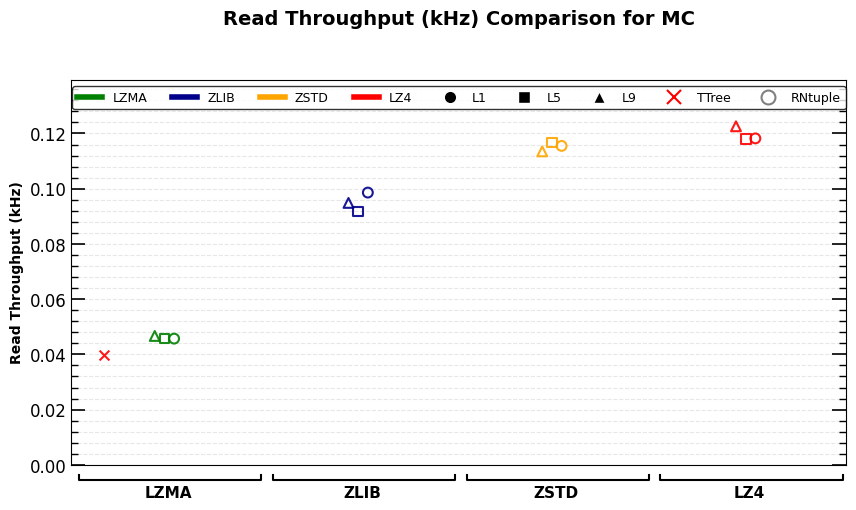

In [6]:
# Read Throughput plots for MC

df = pd.read_csv('All_Compression_Algo_metrics.csv')
df = df[df["Cores"] == 1].copy()

df["Algo"] = df["Algo"].astype(str).str.strip().str.upper()
df["AODtype"] = df["AODtype"].astype(str).str.strip().str.upper()
df["Level"] = pd.to_numeric(df["Level"], errors='coerce').fillna(0).astype(int)

metric_col = "Job_Read_Throughput(events/ms)"
display_name = "Read Throughput (kHz)"


algos = ["LZMA", "ZLIB", "ZSTD", "LZ4"]
marker_symbols = {1: "o", 5: "s", 9: "^"}
color_map = {"LZMA": "green", "ZLIB": "darkblue", "ZSTD": "orange", "LZ4": "red"}

fig, ax = plt.subplots(figsize=(10, 5))

ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=12)
ax.tick_params(which='major', length=10, width=1.2)
ax.tick_params(which='minor', length=5, width=1.0)

ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.xaxis.set_minor_locator(AutoMinorLocator(2)) 

ax.grid(True, which='both', axis='both', linestyle='--', alpha=0.3, zorder=0)

jitter_offset = 0.18 
level_shift = 0.05   

level_adjust = {1: -level_shift, 5: 0, 9: level_shift}

for i, algo in enumerate(algos):
    for fmt in ["TTREE", "RNTUPLE"]:
        for lvl in [1, 5, 9]:
            subset = df[(df["Algo"] == algo) & (df["AODtype"] == fmt) & (df["Level"] == lvl)]
            if not subset.empty:
                val = subset[metric_col].mean()
                
                fmt_pos = i - jitter_offset if fmt == "TTREE" else i + jitter_offset
                
                x_pos = fmt_pos - level_adjust[lvl]
                
                ax.scatter(x_pos-0.2, val, 
                           marker="x" if fmt == "TTREE" else marker_symbols[lvl], 
                           color="red" if fmt == "TTREE" else color_map[algo], 
                           s=50, 
                           edgecolors=None if fmt == "TTREE" else color_map[algo], 
                           linewidths=1.5,
                           facecolors="red" if fmt == "TTREE" else ('none' if fmt == "RNTUPLE" else color_map[algo]),
                           alpha=0.9,
                           zorder=4)

plt.draw()

y_min, y_max = ax.get_ylim()
bracket_y = 0 - (y_max - y_min) * 0.06 
bracket_height = (y_max - y_min) * 0.02

for i, algo in enumerate(algos):
    left_edge = i - jitter_offset - 0.28
    right_edge = i + jitter_offset + 0.3
    
    ax.plot([left_edge, left_edge, right_edge, right_edge],
            [bracket_y + bracket_height, bracket_y, bracket_y, bracket_y + bracket_height],
            color='black', lw=1.5, clip_on=False)
    
    ax.text(i, bracket_y - (y_max - y_min) * 0.02, algo, 
            ha='center', va='top', fontsize=11, fontweight='bold', clip_on=False)

ax.set_title(f"{display_name} Comparison for MC", fontsize=14, fontweight='bold', pad=40)

algo_handles = [Line2D([0], [0], color=color_map[a], lw=4, label=a.upper()) for a in algos]

format_handles = [
    Line2D([0], [0], marker='o', color='w', label='L1', markerfacecolor='black', markersize=9),
    Line2D([0], [0], marker='s', color='w', label='L5', markerfacecolor='black', markersize=9),
    Line2D([0], [0], marker='^', color='w', label='L9', markerfacecolor='black', markersize=9),
    Line2D([0], [0], marker='x', color='w', label='TTree', markeredgecolor='red', markerfacecolor='red', markeredgewidth=1.5, markersize=10),
    Line2D([0], [0], marker='o', color='w', label='RNtuple', markerfacecolor='none', markeredgecolor='gray', markeredgewidth=1.5, markersize=10)
]

ax.legend(handles=algo_handles + format_handles, loc='upper center', 
          bbox_to_anchor=(0.5, 1.0), ncol=9, frameon=True, edgecolor='black', fontsize=9)

ax.set_ylabel(display_name, fontsize=10, fontweight='bold')
ax.set_xticks([]) 
ax.set_xlim(-0.5, len(algos) - 0.5)


ax.set_ylim(0, y_max * 1.1)

plt.show()

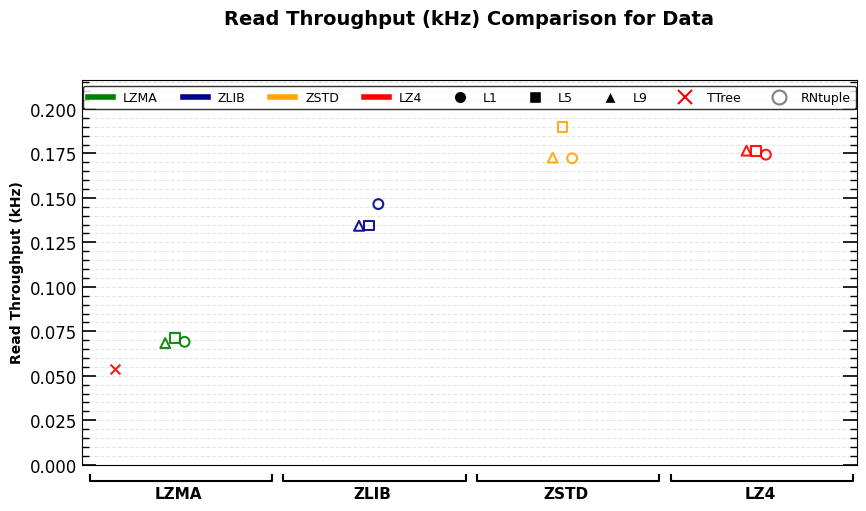

In [7]:
# Read Throughput plots for Data

df = pd.read_csv('../All_Compression_Algo_metrics_data.csv')


df["Algo"] = df["Algo"].astype(str).str.strip().str.upper()
df["AODtype"] = df["AODtype"].astype(str).str.strip().str.upper()
df["Level"] = pd.to_numeric(df["Level"], errors='coerce').fillna(0).astype(int)

metric_col = "Job_Read_Throughput(events/ms)"
display_name = "Read Throughput (kHz)"


algos = ["LZMA", "ZLIB", "ZSTD", "LZ4"]
marker_symbols = {1: "o", 5: "s", 9: "^"}
color_map = {"LZMA": "green", "ZLIB": "darkblue", "ZSTD": "orange", "LZ4": "red"}
fig, ax = plt.subplots(figsize=(10, 5))

ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=12)
ax.tick_params(which='major', length=10, width=1.2)
ax.tick_params(which='minor', length=5, width=1.0)

ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.xaxis.set_minor_locator(AutoMinorLocator(2)) 

ax.grid(True, which='both', axis='both', linestyle='--', alpha=0.3, zorder=0)

jitter_offset = 0.18 
level_shift = 0.05   

level_adjust = {1: -level_shift, 5: 0, 9: level_shift}

for i, algo in enumerate(algos):
    for fmt in ["TTREE", "RNTUPLE"]:
        for lvl in [1, 5, 9]:
            subset = df[(df["Algo"] == algo) & (df["AODtype"] == fmt) & (df["Level"] == lvl)]
            if not subset.empty:
                val = subset[metric_col].mean()
                
                fmt_pos = i - jitter_offset if fmt == "TTREE" else i + jitter_offset
                
                x_pos = fmt_pos - level_adjust[lvl]
                
                ax.scatter(x_pos-0.2, val, 
                           marker="x" if fmt == "TTREE" else marker_symbols[lvl], 
                           color="red" if fmt == "TTREE" else color_map[algo], 
                           s=50, 
                           edgecolors=None if fmt == "TTREE" else color_map[algo], 
                           linewidths=1.5,
                           facecolors="red" if fmt == "TTREE" else ('none' if fmt == "RNTUPLE" else color_map[algo]),
                           alpha=0.9,
                           zorder=4)

plt.draw()

y_min, y_max = ax.get_ylim()
bracket_y = 0 - (y_max - y_min) * 0.06 
bracket_height = (y_max - y_min) * 0.02

for i, algo in enumerate(algos):
    left_edge = i - jitter_offset - 0.28
    right_edge = i + jitter_offset + 0.3
    
    ax.plot([left_edge, left_edge, right_edge, right_edge],
            [bracket_y + bracket_height, bracket_y, bracket_y, bracket_y + bracket_height],
            color='black', lw=1.5, clip_on=False)
    
    ax.text(i, bracket_y - (y_max - y_min) * 0.02, algo, 
            ha='center', va='top', fontsize=11, fontweight='bold', clip_on=False)

ax.set_title(f"{display_name} Comparison for Data", fontsize=14, fontweight='bold', pad=40)

algo_handles = [Line2D([0], [0], color=color_map[a], lw=4, label=a.upper()) for a in algos]

format_handles = [
    Line2D([0], [0], marker='o', color='w', label='L1', markerfacecolor='black', markersize=9),
    Line2D([0], [0], marker='s', color='w', label='L5', markerfacecolor='black', markersize=9),
    Line2D([0], [0], marker='^', color='w', label='L9', markerfacecolor='black', markersize=9),
    Line2D([0], [0], marker='x', color='w', label='TTree', markeredgecolor='red', markerfacecolor='red', markeredgewidth=1.5, markersize=10),
    Line2D([0], [0], marker='o', color='w', label='RNtuple', markerfacecolor='none', markeredgecolor='gray', markeredgewidth=1.5, markersize=10)
]

ax.legend(handles=algo_handles + format_handles, loc='upper center', 
          bbox_to_anchor=(0.5, 1.0), ncol=9, frameon=True, edgecolor='black', fontsize=9)

ax.set_ylabel(display_name, fontsize=10, fontweight='bold')
ax.set_xticks([]) 
ax.set_xlim(-0.5, len(algos) - 0.5)


ax.set_ylim(0, y_max * 1.1)

plt.show()

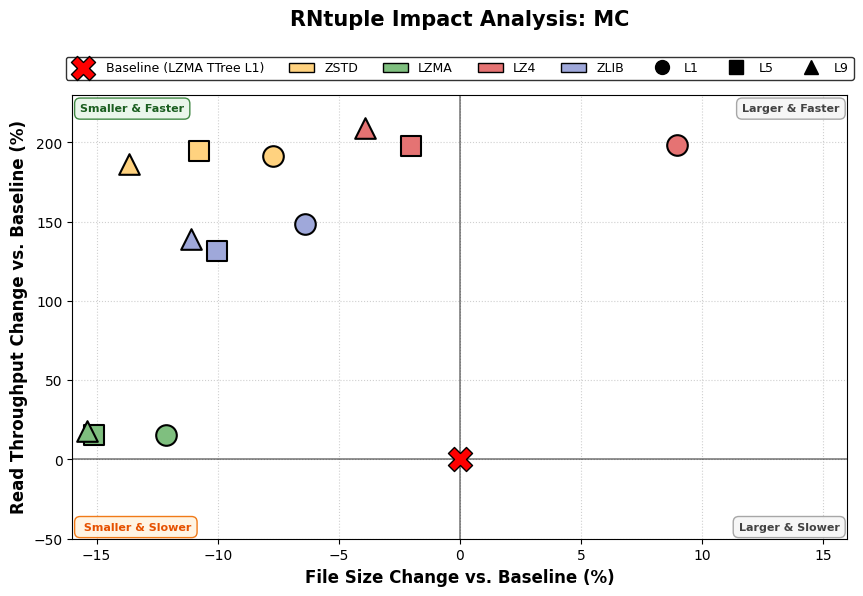


Read throughput change (%) Lists [L1, L5, L9]:
LZMA : [15.26, 15.45, 17.69]
ZSTD : [191.27, 194.37, 186.28]
LZ4  : [198.14, 197.7, 209.18]
ZLIB : [148.65, 131.31, 139.21]


In [8]:
# RNtuple Impact Analysis for MC

TARGET_METRIC = "Job_Read_Throughput(events/ms)"
METRIC_LABEL = "Read Throughput"
TARGET_CORE = 1
CORE_1_EVENT_STR = "7000events" 

COLORS = {"ZSTD": "#ffd27f", "LZMA": "#7fbf7f", "LZ4": "#e57373", "ZLIB": "#9fa8da"}
MARKERS = {1: "o", 5: "s", 9: "^"}


df_perf_raw = pd.read_csv('All_Compression_Algo_metrics.csv')
df_size_raw = pd.read_csv("../file_size_MC.csv")


df_perf = df_perf_raw.copy()
df_perf['Algo'] = df_perf['Algo'].astype(str).str.upper().str.strip()
df_perf['AODtype'] = df_perf['AODtype'].astype(str).str.upper().str.strip()
df_perf['Level'] = pd.to_numeric(df_perf['Level'], errors='coerce')


id_cols = ['Algo', 'AOD_type']

size_cols = [c for c in df_size_raw.columns if CORE_1_EVENT_STR in c]
df_size_long = df_size_raw[id_cols + size_cols].melt(id_vars=id_cols, var_name='Metadata', value_name='Size_GB')


df_size_long['Level'] = df_size_long['Metadata'].str.extract(r'level(\d+)').astype(int)
df_size_long['Algo'] = df_size_long['Algo'].astype(str).str.upper().str.strip()
df_size_long['AODtype'] = df_size_long['AOD_type'].astype(str).str.upper().str.strip()


ref_perf_mask = (df_perf['Algo']=='LZMA') & (df_perf['AODtype']=='TTREE') & \
                (df_perf['Level']==1) & (df_perf['Cores']==TARGET_CORE)

ref_size_mask = (df_size_long['Algo']=='LZMA') & (df_size_long['AODtype']=='TTree'.upper()) & \
                (df_size_long['Level']==1)

if df_perf[ref_perf_mask].empty or df_size_long[ref_size_mask].empty:
    print("--- Error: Baseline Not Found ---")
    print(f"Perf entries found: {len(df_perf[ref_perf_mask])}")
    print(f"Size entries found: {len(df_size_long[ref_size_mask])}")
    raise ValueError("Baseline (LZMA TTREE L1) is missing from your CSV data.")

ref_perf = df_perf[ref_perf_mask][TARGET_METRIC].mean()
ref_size = df_size_long[ref_size_mask]['Size_GB'].mean()


results = []
for algo in ["ZSTD", "LZMA", "LZ4", "ZLIB"]:
    for lvl in [1, 5, 9]:
        p_val = df_perf[(df_perf['Algo']==algo) & (df_perf['AODtype']=='RNTUPLE') & 
                        (df_perf['Level']==lvl) & (df_perf['Cores']==TARGET_CORE)][TARGET_METRIC].mean()
        
        s_val = df_size_long[(df_size_long['Algo']==algo) & (df_size_long['AODtype']=='RNTUPLE') & 
                            (df_size_long['Level']==lvl)]['Size_GB'].mean()
        
        if pd.notnull(p_val) and pd.notnull(s_val):
            results.append({
                'Algo': algo, 'Level': lvl,
                'S_Gain': (s_val - ref_size) / ref_size * 100,
                'P_Gain': (p_val - ref_perf) / ref_perf * 100
            })

df_plot = pd.DataFrame(results)


fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(top=0.85)


ax.axhline(0, color='black', linestyle='-', lw=1.2, alpha=0.5)
ax.axvline(0, color='black', linestyle='-', lw=1.2, alpha=0.5)


ref_handle = ax.scatter(0, 0, color='red', marker='X', s=300, label="Baseline (LZMA TTree L1)", zorder=10, edgecolors='black')


for algo in ["ZSTD", "LZMA", "LZ4", "ZLIB"]:
    sub = df_plot[df_plot['Algo'] == algo]
    if not sub.empty:
        for _, row in sub.iterrows():
            ax.scatter(row['S_Gain'], row['P_Gain'], color=COLORS[algo], 
                       marker=MARKERS[row['Level']], s=220, edgecolors='black', 
                       linewidths=1.5, zorder=5)


box_win = dict(facecolor='#e8f5e9', alpha=0.9, edgecolor='#2e7d32', boxstyle='round,pad=0.5')
box_slow = dict(facecolor='#fff3e0', alpha=0.9, edgecolor='#ef6c00', boxstyle='round,pad=0.5')
box_neutral = dict(facecolor='#f5f5f5', alpha=0.9, edgecolor='#9e9e9e', boxstyle='round,pad=0.5')


ax.text(0.01, 0.98, "Smaller & Faster", transform=ax.transAxes, 
        color='#1b5e20', fontweight='bold', fontsize=8, va='top', bbox=box_win)

ax.text(0.01, 0.015, " Smaller & Slower", transform=ax.transAxes, 
        color='#e65100', fontweight='bold', fontsize=8, va='bottom', bbox=box_slow)

ax.text(0.99, 0.98
        , "Larger & Faster", transform=ax.transAxes, 
        color='#424242', fontweight='bold', fontsize=8, va='top', ha='right', bbox=box_neutral)

ax.text(0.99, 0.015, "Larger & Slower", transform=ax.transAxes, 
        color='#424242', fontweight='bold', fontsize=8, va='bottom', ha='right', bbox=box_neutral)


ax.set_xlim(-16, 16) 


y_limit = max(df_plot['P_Gain'].abs().max(), 20) * 1.1
ax.set_ylim(-50, y_limit)

ax.set_xlabel("File Size Change vs. Baseline (%)", fontweight='bold', fontsize=12)
ax.set_ylabel(f"{METRIC_LABEL} Change vs. Baseline (%)", fontweight='bold', fontsize=12)
ax.set_title(f"RNtuple Impact Analysis: MC", fontsize=15, fontweight='bold', pad=50)


algo_h = [mpatches.Patch(facecolor=COLORS[a], edgecolor='black', label=a) for a in ["ZSTD", "LZMA", "LZ4", "ZLIB"]]
lvl_h = [Line2D([0], [0], color='black', marker=m, linestyle='None', markersize=10, label=f'L{l}') for l, m in MARKERS.items()]
ax.legend(handles=[ref_handle] + algo_h + lvl_h, loc='lower center', 
           bbox_to_anchor=(0.5, 1.02), ncol=8, frameon=True, edgecolor='black', fontsize=9)

ax.grid(True, linestyle=":", alpha=0.6)
plt.show()
plt.show()

# Percentage read throughput lists
print("\n" + "="*50)
print("Read throughput change (%) Lists [L1, L5, L9]:")
print("="*50)

for algo in ["LZMA", "ZSTD", "LZ4", "ZLIB"]:
    
    sub_df = df_plot[df_plot['Algo'] == algo].sort_values(by='Level')
    
    
    p_gain_list = [round(val, 2) for val in sub_df['P_Gain'].tolist()]
    
    print(f"{algo:<5}: {p_gain_list}")
print("="*50)

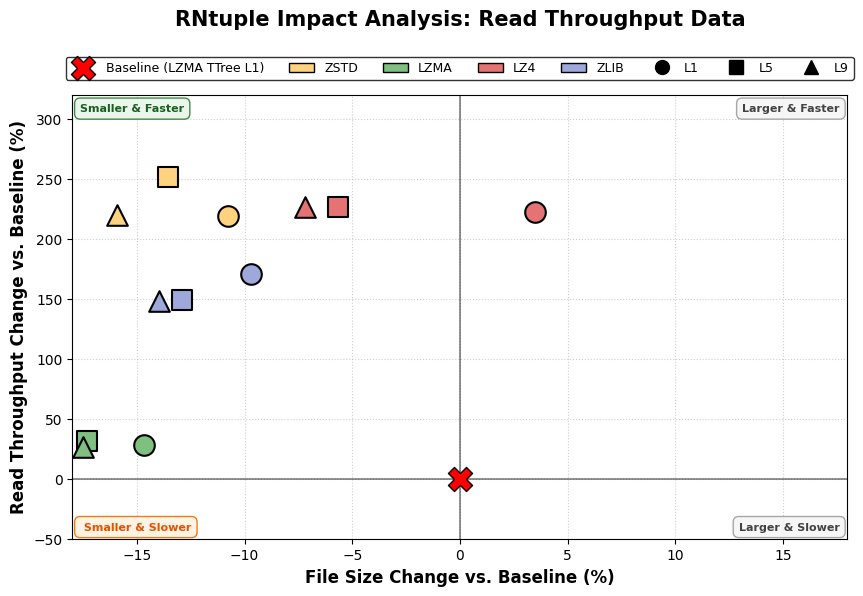


Read throughput change (%) Lists [L1, L5, L9]:
LZMA : [27.81, 31.36, 26.48]
ZSTD : [218.68, 251.39, 219.36]
LZ4  : [222.47, 226.3, 226.59]
ZLIB : [170.99, 148.75, 148.43]


In [10]:
# RNtuple Impact Analysis for Data

TARGET_METRIC = "Job_Read_Throughput(events/ms)"
METRIC_LABEL = "Read Throughput"
TARGET_CORE = 1
CORE_1_EVENT_STR = "7000events" 

COLORS = {"ZSTD": "#ffd27f", "LZMA": "#7fbf7f", "LZ4": "#e57373", "ZLIB": "#9fa8da"}
MARKERS = {1: "o", 5: "s", 9: "^"}


df_perf_raw = pd.read_csv('../All_Compression_Algo_metrics_data.csv')
df_size_raw = pd.read_csv("../file_size_data.csv")


df_perf = df_perf_raw.copy()
df_perf['Algo'] = df_perf['Algo'].astype(str).str.upper().str.strip()
df_perf['AODtype'] = df_perf['AODtype'].astype(str).str.upper().str.strip()
df_perf['Level'] = pd.to_numeric(df_perf['Level'], errors='coerce')


id_cols = ['Algo', 'AOD_type']

size_cols = [c for c in df_size_raw.columns if CORE_1_EVENT_STR in c]
df_size_long = df_size_raw[id_cols + size_cols].melt(id_vars=id_cols, var_name='Metadata', value_name='Size_GB')


df_size_long['Level'] = df_size_long['Metadata'].str.extract(r'level(\d+)').astype(int)
df_size_long['Algo'] = df_size_long['Algo'].astype(str).str.upper().str.strip()
df_size_long['AODtype'] = df_size_long['AOD_type'].astype(str).str.upper().str.strip()


ref_perf_mask = (df_perf['Algo']=='LZMA') & (df_perf['AODtype']=='TTREE') & \
                (df_perf['Level']==1)

ref_size_mask = (df_size_long['Algo']=='LZMA') & (df_size_long['AODtype']=='TTree'.upper()) & \
                (df_size_long['Level']==1)

if df_perf[ref_perf_mask].empty or df_size_long[ref_size_mask].empty:
    print("--- Error: Baseline Not Found ---")
    print(f"Perf entries found: {len(df_perf[ref_perf_mask])}")
    print(f"Size entries found: {len(df_size_long[ref_size_mask])}")
    raise ValueError("Baseline (LZMA TTREE L1) is missing from your CSV data.")

ref_perf = df_perf[ref_perf_mask][TARGET_METRIC].mean()
ref_size = df_size_long[ref_size_mask]['Size_GB'].mean()


results = []
for algo in ["ZSTD", "LZMA", "LZ4", "ZLIB"]:
    for lvl in [1, 5, 9]:
        p_val = df_perf[(df_perf['Algo']==algo) & (df_perf['AODtype']=='RNTUPLE') & 
                        (df_perf['Level']==lvl)][TARGET_METRIC].mean()
        
        s_val = df_size_long[(df_size_long['Algo']==algo) & (df_size_long['AODtype']=='RNTUPLE') & 
                            (df_size_long['Level']==lvl)]['Size_GB'].mean()
        
        if pd.notnull(p_val) and pd.notnull(s_val):
            results.append({
                'Algo': algo, 'Level': lvl,
                'S_Gain': (s_val - ref_size) / ref_size * 100,
                'P_Gain': (p_val - ref_perf) / ref_perf * 100
            })

df_plot = pd.DataFrame(results)


fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(top=0.85)


ax.axhline(0, color='black', linestyle='-', lw=1.2, alpha=0.5)
ax.axvline(0, color='black', linestyle='-', lw=1.2, alpha=0.5)


ref_handle = ax.scatter(0, 0, color='red', marker='X', s=300, label="Baseline (LZMA TTree L1)", zorder=10, edgecolors='black')


for algo in ["ZSTD", "LZMA", "LZ4", "ZLIB"]:
    sub = df_plot[df_plot['Algo'] == algo]
    if not sub.empty:
        for _, row in sub.iterrows():
            ax.scatter(row['S_Gain'], row['P_Gain'], color=COLORS[algo], 
                       marker=MARKERS[row['Level']], s=220, edgecolors='black', 
                       linewidths=1.5, zorder=5)


box_win = dict(facecolor='#e8f5e9', alpha=0.9, edgecolor='#2e7d32', boxstyle='round,pad=0.5')
box_slow = dict(facecolor='#fff3e0', alpha=0.9, edgecolor='#ef6c00', boxstyle='round,pad=0.5')
box_neutral = dict(facecolor='#f5f5f5', alpha=0.9, edgecolor='#9e9e9e', boxstyle='round,pad=0.5')


ax.text(0.01, 0.98, "Smaller & Faster", transform=ax.transAxes, 
        color='#1b5e20', fontweight='bold', fontsize=8, va='top', bbox=box_win)

ax.text(0.01, 0.015, " Smaller & Slower", transform=ax.transAxes, 
        color='#e65100', fontweight='bold', fontsize=8, va='bottom', bbox=box_slow)

ax.text(0.99, 0.98
        , "Larger & Faster", transform=ax.transAxes, 
        color='#424242', fontweight='bold', fontsize=8, va='top', ha='right', bbox=box_neutral)

ax.text(0.99, 0.015, "Larger & Slower", transform=ax.transAxes, 
        color='#424242', fontweight='bold', fontsize=8, va='bottom', ha='right', bbox=box_neutral)


ax.set_xlim(-18, 18) 


y_limit = max(df_plot['P_Gain'].abs().max(), 20) * 1.4
ax.set_ylim(-50, 320)

ax.set_xlabel("File Size Change vs. Baseline (%)", fontweight='bold', fontsize=12)
ax.set_ylabel(f"{METRIC_LABEL} Change vs. Baseline (%)", fontweight='bold', fontsize=12)
ax.set_title(f"RNtuple Impact Analysis: {METRIC_LABEL} Data", fontsize=15, fontweight='bold', pad=50)


algo_h = [mpatches.Patch(facecolor=COLORS[a], edgecolor='black', label=a) for a in ["ZSTD", "LZMA", "LZ4", "ZLIB"]]
lvl_h = [Line2D([0], [0], color='black', marker=m, linestyle='None', markersize=10, label=f'L{l}') for l, m in MARKERS.items()]
ax.legend(handles=[ref_handle] + algo_h + lvl_h, loc='lower center', 
           bbox_to_anchor=(0.5, 1.02), ncol=8, frameon=True, edgecolor='black', fontsize=9)

ax.grid(True, linestyle=":", alpha=0.6)
plt.show()
plt.show()

# Percentage read throughput lists
print("\n" + "="*50)
print("Read throughput change (%) Lists [L1, L5, L9]:")
print("="*50)

for algo in ["LZMA", "ZSTD", "LZ4", "ZLIB"]:
    
    sub_df = df_plot[df_plot['Algo'] == algo].sort_values(by='Level')
    
    
    p_gain_list = [round(val, 2) for val in sub_df['P_Gain'].tolist()]
    
    print(f"{algo:<5}: {p_gain_list}")
print("="*50)